# 03 Feature Engineering

Builds the feature table from the cleaned statement-level
data (`train_1m_rows_clean.parquet`). The target is defined per customer, while the raw data has
monthly statement rows, so the central feature-engineering decision is to summarize each customer's
history without learning any imputation/scaling/PCA parameters yet.

Reasoning for the order:

1. **Redundancy removal first**: EDA showed many near-duplicate numeric columns. Dropping one side of
   highly correlated base-feature pairs before aggregation prevents redundant variables from being
   multiplied across `mean/std/min/max/last` summaries.
2. **Customer-level aggregation**: the model predicts one label per customer, so every customer must
   become one row before supervised learning.
3. **Missing-data signals**: EDA showed missingness differs by target, so missingness should become a
   signal rather than being erased too early.
4. **Derived features**: add a small number of interpretable trend/range/ratio features based on EDA
   signal, not a large arbitrary expansion.
5. **Categorical encoding**: encode the latest categorical state and category instability after the
   statement history is collapsed.
6. **Save raw numeric feature table**: keep `NaN`s and original scales so leak-prone transforms are fit
   only inside cross-validation.

Imputation, scaling, and PCA are **not** baked into the saved table — they are bundled into a
`scikit-learn` Pipeline (step 7) that modeling fits **inside cross-validation**, so no test-set
statistics leak into preprocessing.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Apple Accelerate + numpy raise spurious matmul FPE warnings; they fire on clean data too.
warnings.filterwarnings('ignore', category=RuntimeWarning)

LIGHT_MODE = False
N_SAMPLE_ROWS = 100_000

INTERIM = Path('../data/interim')
ROWS_PATH = INTERIM / 'train_1m_rows_clean.parquet'
LABELS_PATH = INTERIM / 'train_1m_labels.parquet'
assert ROWS_PATH.exists(), 'Run notebooks/01_preprocessing.ipynb first (writes the cleaned parquet).'

ID, DATE = 'customer_ID', 'S_2'

def read_rows_for_notebook(path, n_rows):
    if not LIGHT_MODE:
        return pd.read_parquet(path)
    parquet_file = pq.ParquetFile(path)
    return next(parquet_file.iter_batches(batch_size=n_rows)).to_pandas()

rows = read_rows_for_notebook(ROWS_PATH, N_SAMPLE_ROWS).sort_values([ID, DATE])
labels = pd.read_parquet(LABELS_PATH)

feature_cols = [c for c in rows.columns if c not in (ID, DATE)]
numeric_cols = rows[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in feature_cols if c not in numeric_cols]
print(f'rows {rows.shape} | numeric {len(numeric_cols)} | categorical {len(cat_cols)}')

rows (1000012, 189) | numeric 175 | categorical 12


## 1. Redundancy Removal (base features)

EDA found many near-duplicate features. We drop one of each base-feature pair with |r| > 0.95
(keeping the one with lower missingness) *before* aggregating, so the redundancy is not multiplied
across the five aggregation statistics. Only reasonably complete features (<50% missing) enter the
correlation screen because sparse columns can have unstable correlations; sparse columns are still
kept elsewhere because their missingness may be informative.


In [2]:
complete = [c for c in numeric_cols if rows[c].isna().mean() < 0.5]
corr = rows[complete].fillna(rows[complete].median(numeric_only=True)).corr().abs()
miss = rows[complete].isna().mean()

cols = corr.columns.tolist()
drop = set()
for i, a in enumerate(cols):
    if a in drop:
        continue
    for b in cols[i + 1:]:
        if b in drop:
            continue
        if corr.loc[a, b] > 0.95:
            drop.add(b if miss[a] <= miss[b] else a)

num_keep = [c for c in numeric_cols if c not in drop]
print(f'dropped {len(drop)} redundant base features: {sorted(drop)}')
print(f'numeric features kept: {len(num_keep)}')

dropped 9 redundant base features: ['B_23', 'B_37', 'D_104', 'D_119', 'D_141', 'D_143', 'D_74', 'R_24', 'S_22']
numeric features kept: 166


## 2. Customer-Level Aggregation

The target is per customer, so each customer's statement history is collapsed to one row. This is not
modeling yet; it is aligning the data grain with the prediction target.

For every numeric feature we take **mean, std, min, max, last**:

- `mean`: typical customer level
- `std`: volatility
- `min/max`: extremes
- `last`: most recent known state, often most relevant for future default

For categoricals we take the **last** value (to encode the latest state) and **nunique** (how much the
category changed over time). We also keep **statement_count** and **customer_span_days** to capture
history length/tenure.


In [3]:
agg_num = rows.groupby(ID)[num_keep].agg(['mean', 'std', 'min', 'max', 'last'])
agg_num.columns = [f'{col}__{stat}' for col, stat in agg_num.columns]

cat_last = rows.groupby(ID)[cat_cols].last().add_suffix('__last')          # strings, encoded below
cat_nunique = rows.groupby(ID)[cat_cols].nunique().add_suffix('__nunique').astype('int16')

statement_count = rows.groupby(ID).size().rename('statement_count').astype('int16')
customer_span_days = (rows.groupby(ID)[DATE].max() - rows.groupby(ID)[DATE].min()).dt.days.rename('customer_span_days')

print('numeric aggregates:', agg_num.shape, '| categorical last:', cat_last.shape)
agg_num.head()

numeric aggregates: (83121, 830) | categorical last: (83121, 12)


,P_2__mean,P_2__std,P_2__min,P_2__max,P_2__last,D_39__mean,D_39__std,D_39__min,D_39__max,D_39__last,...,D_144__mean,D_144__std,D_144__min,D_144__max,D_144__last,D_145__mean,D_145__std,D_145__min,D_145__max,D_145__last
customer_ID,,,,,,,,,,,,,,,,,,,,,
00000fd6641609c6ece5454664794f0340ad84dddce9a267a310b5ae68e9d8e5,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,0.178126,...,0.004224,0.002861,0.000110,0.009568,0.003169,0.004902,0.002729,0.000796,0.009390,0.008514
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad51ca8b8c4a24cefed,0.891679,0.042325,0.805045,0.940382,0.871900,0.004655,0.002863,0.000180,0.008680,0.005573,...,0.004380,0.002633,0.000633,0.009436,0.006944,0.004222,0.003422,0.000123,0.009666,0.000905
0000f99513770170a1aba690daeeb8a96da4a39f11fc27da5c30a79db61c1e85,0.406721,0.009114,0.391495,0.424624,0.424624,0.124733,0.209513,0.000269,0.647319,0.531173,...,0.005054,0.003242,0.000765,0.009371,0.003350,0.739022,0.025978,0.727649,0.824853,0.734467
000201146e53cacdde1c7e9d29f4d3c46fd4d9231a3744aa39fb9c6afa79b708,0.872843,0.062567,0.730128,0.955898,0.955898,0.276820,0.189414,0.004161,0.598046,0.182730,...,0.005853,0.002772,0.000871,0.009047,0.002604,0.006152,0.002945,0.000490,0.009263,0.008785
00031e8be98bc3411f6037cbd4d3eeaf24b3ae221682b77900533c9bb36ec41f,0.721835,0.045837,0.665003,0.828111,0.828111,0.195796,0.177785,0.000410,0.627605,0.120221,...,0.466422,0.073275,0.333697,0.508820,0.508820,0.095089,0.002369,0.091536,0.099441,0.093622


## 3. Missing-Data Signals

EDA showed missingness is itself predictive: missing rates vary by target and some sparse variables
have different missingness patterns for defaulters vs non-defaulters. We therefore keep missingness
as explicit information instead of filling it immediately.

We add two kinds of signals:

- per-feature **was_missing** flags for features where a customer never had an observed value
- **missing_feature_count** for the customer's most recent statement

Actual imputation is deferred to the modeling pipeline so imputation values are learned inside each
cross-validation fold.


In [4]:
flag_df = pd.DataFrame(index=agg_num.index)
for f in num_keep:
    mean_col = f'{f}__mean'
    if agg_num[mean_col].isna().mean() > 0.05:
        flag_df[f'{f}__was_missing'] = agg_num[mean_col].isna().astype('int8')

last_cols = [f'{f}__last' for f in num_keep]
missing_feature_count = agg_num[last_cols].isna().sum(axis=1).rename('missing_feature_count').astype('int16')

print(f'missing-indicator flags: {flag_df.shape[1]} | missing_feature_count added')

missing-indicator flags: 37 | missing_feature_count added


## 4. Derived Features

Beyond aggregates, we engineer features that capture *behavior over time* and *cross-group
relationships* (the prefix taxonomy is P = payment, B = balance, S = spend, D = delinquency,
R = risk).

The trend/range features start with a **core set of 12 numeric variables with the strongest
statement-level association with `target`**, ranked by absolute point-biserial correlation and with
univariate AUC kept as a sanity check. The cutoff of 12 is a feature-budget choice: each selected
raw variable creates two derived columns (`trend` and `range`), so the core set adds 24 temporal
features before the ratio features. That is enough to capture behavior for the strongest EDA signals
without creating trend/range versions of every anonymized column.

After that, we check feature-family coverage. If the top-12 core set misses any AMEX family
(`P`, `B`, `D`, `R`, or `S`), we add the **best-ranked available feature from the missing family**.
This keeps the rule objective while avoiding a derived-feature set that only reflects the dominant
payment/balance/delinquency groups and ignores risk or spend dynamics.

Derived feature meanings:

- **trend** = last - mean, measuring whether the most recent statement is better/worse than the
  customer's own history.
- **range** = max - min, measuring within-customer volatility for the selected high-signal or
  group-representative raw variables.
- **cross-group ratios** = recent payment / balance and spend / balance, motivated by credit-risk
  utilization-style relationships.

These are still simple transformations of observed history; imputation and scaling remain deferred
to the modeling pipeline.


In [5]:
from sklearn.metrics import roc_auc_score

row_targets = rows[[ID]].merge(labels, on=ID, how='left', validate='many_to_one')['target'].to_numpy()
signal_rows = []
for f in num_keep:
    s = rows[f]
    mask = s.notna().to_numpy()
    if mask.sum() < 100:
        continue
    x = s[mask].to_numpy()
    y = row_targets[mask]
    if len(np.unique(y)) < 2 or np.nanstd(x) == 0:
        continue
    corr = np.corrcoef(x, y)[0, 1]
    auc = roc_auc_score(y, x)
    signal_rows.append({
        'feature': f,
        'feature_group': f.split('_', 1)[0],
        'abs_corr_with_target': abs(float(corr)),
        'univariate_auc': max(float(auc), 1 - float(auc)),
        'missing_rate': float(s.isna().mean()),
    })

signal_for_derived = (
    pd.DataFrame(signal_rows)
    .sort_values(['abs_corr_with_target', 'univariate_auc'], ascending=False)
    .reset_index(drop=True)
)

CORE_N = 12
REQUIRED_GROUPS = ['P', 'B', 'D', 'R', 'S']

# Core budget: 12 variables x 2 temporal features = 24 derived columns.
selected = signal_for_derived.head(CORE_N)['feature'].tolist()
selected_groups = set(signal_for_derived.head(CORE_N)['feature_group'])
coverage_additions = []
for group in REQUIRED_GROUPS:
    if group in selected_groups:
        continue
    best = signal_for_derived.loc[signal_for_derived['feature_group'] == group, 'feature']
    if not best.empty:
        feature = best.iloc[0]
        selected.append(feature)
        coverage_additions.append({'feature_group': group, 'added_feature': feature})

TOP = selected
print('derived-feature candidates: top 12 by EDA-style signal ranking, plus best feature from any missing family')
display(signal_for_derived[signal_for_derived['feature'].isin(TOP)].round(3))
if coverage_additions:
    print('group coverage additions:', coverage_additions)
else:
    print('top 12 already covered every required feature group')

derived = pd.DataFrame(index=agg_num.index)
for f in TOP:
    derived[f'{f}__trend'] = agg_num[f'{f}__last'] - agg_num[f'{f}__mean']
    derived[f'{f}__range'] = agg_num[f'{f}__max'] - agg_num[f'{f}__min']

eps = 1e-6
ratios = {'payment_to_balance': ('P_2', 'B_1'), 'spend_to_balance': ('S_3', 'B_1')}
for name, (a, b) in ratios.items():
    if f'{a}__last' in agg_num.columns and f'{b}__last' in agg_num.columns:
        derived[name] = agg_num[f'{a}__last'] / (agg_num[f'{b}__last'].abs() + eps)

print(f'derived features: {derived.shape[1]} (trend/range over {len(TOP)} selected features + ratios)')


derived-feature candidates: top 12 by EDA-style signal ranking, plus best feature from any missing family


,feature,feature_group,abs_corr_with_target,univariate_auc,missing_rate
0,P_2,P,0.617,0.892,0.009
1,D_48,D,0.556,0.845,0.130
2,B_9,B,0.519,0.790,0.000
3,D_61,D,0.504,0.819,0.108
4,B_18,B,0.490,0.812,0.000
5,D_44,D,0.488,0.802,0.051
6,B_2,B,0.485,0.790,0.010
7,D_75,D,0.471,0.820,0.000
8,D_55,D,0.461,0.787,0.034
9,B_33,B,0.456,0.755,0.000


group coverage additions: [{'feature_group': 'R', 'added_feature': 'R_1'}, {'feature_group': 'S', 'added_feature': 'S_7'}]
derived features: 30 (trend/range over 14 selected features + ratios)


## 5. Categorical Encoding

One-hot encode each categorical feature's **last** value because the latest observed state is the
categorical analogue of the numeric `last` aggregate. `dummy_na=True` keeps missingness as its own
level, and because preprocessing kept `-1` as a real category, it becomes its own column rather than
being conflated with missing.


In [6]:
# map missing to an explicit 'missing' level (clean column names; no all-zero NaN cols)
cat_encoded = pd.get_dummies(cat_last.fillna('missing'), dtype='int8')
print(f'one-hot columns: {cat_encoded.shape[1]}')
cat_encoded.head()

one-hot columns: 56


,D_63__last_CL,D_63__last_CO,D_63__last_CR,D_63__last_XL,D_63__last_XM,D_63__last_XZ,D_64__last_-1,D_64__last_O,D_64__last_R,D_64__last_U,...,D_117__last_4,D_117__last_5,D_117__last_6,D_117__last_missing,D_120__last_0,D_120__last_1,D_120__last_missing,D_126__last_-1,D_126__last_0,D_126__last_1
customer_ID,,,,,,,,,,,,,,,,,,,,,
00000fd6641609c6ece5454664794f0340ad84dddce9a267a310b5ae68e9d8e5,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad51ca8b8c4a24cefed,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
0000f99513770170a1aba690daeeb8a96da4a39f11fc27da5c30a79db61c1e85,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
000201146e53cacdde1c7e9d29f4d3c46fd4d9231a3744aa39fb9c6afa79b708,0,1,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,1
00031e8be98bc3411f6037cbd4d3eeaf24b3ae221682b77900533c9bb36ec41f,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1


## 6. Assemble & Save Model-Ready Table

Concatenate all feature blocks on `customer_ID`, replace any infinities from ratios with `NaN`, and
attach the `target`. The saved table intentionally remains unscaled and partially missing. That makes
it a stable feature table while leaving all learned preprocessing decisions to the downstream
cross-validation pipeline.


In [7]:
features = pd.concat(
    [agg_num, cat_nunique, cat_encoded, flag_df, derived,
     statement_count, customer_span_days, missing_feature_count],
    axis=1,
)
features = features.replace([np.inf, -np.inf], np.nan)
features = features.join(labels.set_index(ID)['target'])

assert features['target'].isna().sum() == 0, 'some customers have no label'
assert features.drop(columns='target').select_dtypes(exclude='number').shape[1] == 0, 'non-numeric feature remains'

FEATURES_PATH = INTERIM / 'train_features.parquet'
features.to_parquet(FEATURES_PATH, compression='zstd')

manifest = {
    'light_mode': LIGHT_MODE,
    'customers': int(len(features)),
    'total_features': int(features.shape[1] - 1),
    'numeric_base_kept': len(num_keep),
    'redundant_dropped': sorted(drop),
    'numeric_aggregate_cols': int(agg_num.shape[1]),
    'categorical_nunique_cols': int(cat_nunique.shape[1]),
    'categorical_onehot_cols': int(cat_encoded.shape[1]),
    'missing_flag_cols': int(flag_df.shape[1]),
    'derived_cols': int(derived.shape[1]),
    'derived_top_features': TOP,
    'derived_core_n': CORE_N,
    'derived_required_groups': REQUIRED_GROUPS,
    'derived_coverage_additions': coverage_additions,
    'derived_top_feature_rule': 'top 12 numeric features by abs point-biserial correlation with target, then add the best-ranked feature from any missing P/B/D/R/S family; AUC used as tie-breaker/sanity check',
    'target_rate': round(float(features['target'].mean()), 4),
    'output': str(FEATURES_PATH),
}
(INTERIM / 'train_features_manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')
print(f'saved {FEATURES_PATH}  ->  {features.shape[0]} customers x {features.shape[1] - 1} features')
manifest

saved ../data/interim/train_features.parquet  ->  83121 customers x 968 features


{'light_mode': False,
 'customers': 83121,
 'total_features': 968,
 'numeric_base_kept': 166,
 'redundant_dropped': ['B_23',
  'B_37',
  'D_104',
  'D_119',
  'D_141',
  'D_143',
  'D_74',
  'R_24',
  'S_22'],
 'numeric_aggregate_cols': 830,
 'categorical_nunique_cols': 12,
 'categorical_onehot_cols': 56,
 'missing_flag_cols': 37,
 'derived_cols': 30,
 'derived_top_features': ['P_2',
  'D_48',
  'B_9',
  'D_61',
  'B_18',
  'D_44',
  'B_2',
  'D_75',
  'D_55',
  'B_33',
  'D_58',
  'B_7',
  'R_1',
  'S_7'],
 'derived_core_n': 12,
 'derived_required_groups': ['P', 'B', 'D', 'R', 'S'],
 'derived_coverage_additions': [{'feature_group': 'R', 'added_feature': 'R_1'},
  {'feature_group': 'S', 'added_feature': 'S_7'}],
 'derived_top_feature_rule': 'top 12 numeric features by abs point-biserial correlation with target, then add the best-ranked feature from any missing P/B/D/R/S family; AUC used as tie-breaker/sanity check',
 'target_rate': 0.2696,
 'output': '../data/interim/train_features.par

## 7. Optional Hold-Out Feature Table

If `data/interim/test_1m_rows.parquet` exists, rebuild `test_features_holdout.parquet` from those
saved 1M hold-out rows using the **current** training feature schema. This prevents the modeling
notebook from seeing stale hold-out columns after we change the feature-engineering rules.

This step does **not** read the original raw monthly Kaggle CSV. It uses the already-saved hold-out
row subset and `train_labels.csv` only to attach target labels for evaluation.


In [8]:
from pathlib import Path
import subprocess
import sys

cwd = Path.cwd()
if (cwd / 'scripts/build_holdout_test.py').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'scripts/build_holdout_test.py').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not locate project root containing scripts/build_holdout_test.py')

holdout_rows_path = PROJECT_ROOT / 'data/interim/test_1m_rows.parquet'
holdout_features_path = PROJECT_ROOT / 'data/interim/test_features_holdout.parquet'

if holdout_rows_path.exists():
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / 'scripts/build_holdout_test.py'),
            '--from-rows',
            '--train-features', str(PROJECT_ROOT / 'data/interim/train_features.parquet'),
            '--output-dir', str(PROJECT_ROOT / 'data/interim'),
        ],
        check=True,
    )
    holdout_features = pd.read_parquet(holdout_features_path)
    assert list(holdout_features.drop(columns='target').columns) == list(features.drop(columns='target').columns)
    print(f'saved aligned hold-out features -> {holdout_features_path} {holdout_features.shape}')
else:
    print(f'optional hold-out rows not found at {holdout_rows_path}; skipping hold-out feature build')


loaded 1,000,003 raw test rows from /Users/hjiang/school/STATGR5241/amex-default-prediction-project/data/interim/test_1m_rows.parquet


done: {'test_customers': 83053, 'test_rows': 1000003, 'features': 968, 'target_rate': 0.2684, 'disjoint_from_train': True, 'seed': 2026, 'raw_rows_file': '/Users/hjiang/school/STATGR5241/amex-default-prediction-project/data/interim/test_1m_rows.parquet'}


saved aligned hold-out features -> /Users/hjiang/school/STATGR5241/amex-default-prediction-project/data/interim/test_features_holdout.parquet (83053, 969)


## 8. Leak-Free Preprocessing Pipeline

Imputation, scaling, and optional PCA are bundled into a `Pipeline` rather than applied to the saved
table. Placed inside `cross_val_score`, each transform is **fit on the training fold only** and then
applied to the held-out fold. This prevents test-fold statistics from leaking into preprocessing.

The cell below is a **smoke test**, not final modeling: a plain logistic regression confirms the table
trains end-to-end and gives a baseline AUC. Full model comparison, tuning, and final selection belong
in `04_supervised_modeling.ipynb`.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # noqa: F401  (available for dim-reduction in modeling)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = features.drop(columns='target')
y = features['target'].astype(int)

# This pipeline is what modeling will fit per-fold (PCA left commented as an option):
preprocess = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    # ('pca', PCA(n_components=0.95, random_state=5241)),
])
smoke = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=1000))])

# n_jobs=1 keeps folds in-process so the RuntimeWarning filter (cell 1) applies.
cv = StratifiedKFold(5, shuffle=True, random_state=5241)
auc = cross_val_score(smoke, X, y, cv=cv, scoring='roc_auc', n_jobs=1)
print(f'leak-free 5-fold CV ROC-AUC: {auc.round(4)}  mean = {auc.mean():.4f}')

leak-free 5-fold CV ROC-AUC: [0.9551 0.9542 0.9565 0.9552 0.9568]  mean = 0.9556


## 9. Optional PCA Interpretation Audit

PCA is not saved as part of `train_features.parquet`, because any PCA used for modeling must be fit
inside cross-validation. Still, it is useful to understand what PCA would compress in the engineered
feature table. This audit fits a temporary impute → scale → PCA pipeline on the engineered table and
then maps the largest component loadings back to:

- the AMEX feature group (`P/B/D/R/S`), when available
- the engineering block (`mean`, `std`, `last`, `missing flag`, derived trend/range, categorical one-hot, etc.)

Use this section only as interpretation of the feature space. It is not a replacement for leak-free
modeling pipelines in `04`.

,component,explained_variance_ratio,positive_side,negative_side,plain_english_read
0,PC1,0.104617,"P_2__last (+0.08), P_2__min (+0.08), B_18__mea...","D_48__mean (-0.08), D_48__last (-0.08), D_61__...",Higher PC1 is associated with engineered colum...
1,PC2,0.044773,"B_14__max (+0.12), B_13__max (+0.12), B_13__me...","S_6__max (-0.09), S_6__mean (-0.09), S_15__mea...",Higher PC2 is associated with engineered colum...
2,PC3,0.033775,"P_4__mean (+0.09), P_4__max (+0.09), B_18__std...","D_47__min (-0.09), D_42__was_missing (-0.09), ...",Higher PC3 is associated with engineered colum...
3,PC4,0.030168,"R_2__mean (+0.13), R_5__mean (+0.12), R_4__mea...","D_54__min (-0.07), B_11__max (-0.07), D_54__la...",Higher PC4 is associated with engineered colum...
4,PC5,0.021760,"missing_feature_count (+0.11), D_60__min (+0.1...","D_58__range (-0.10), customer_span_days (-0.10...",Higher PC5 is associated with engineered colum...


engineering_block,categorical_nunique,categorical_onehot_last,derived_range,derived_trend,history_length,missing_signal,numeric_last,numeric_max,numeric_mean,numeric_min,numeric_std,other,was_missing
component,,,,,,,,,,,,,
PC1,0.008,0.029,0.023,0.013,0.000,0.002,0.193,0.199,0.205,0.146,0.149,0.002,0.032
PC2,0.007,0.046,0.006,0.003,0.004,0.002,0.172,0.216,0.198,0.166,0.140,0.002,0.037
PC3,0.008,0.051,0.030,0.016,0.004,0.001,0.153,0.182,0.184,0.173,0.152,0.001,0.044
PC4,0.006,0.026,0.015,0.007,0.001,0.001,0.195,0.203,0.213,0.127,0.174,0.001,0.030
PC5,0.016,0.057,0.032,0.006,0.009,0.005,0.140,0.188,0.156,0.195,0.139,0.003,0.056


feature_group,B,D,P,R,S,customer,missing,payment,spend,statement
component,,,,,,,,,,
PC1,0.293,0.443,0.031,0.145,0.084,0.000,0.002,0.001,0.001,0.000
PC2,0.277,0.420,0.017,0.065,0.213,0.002,0.002,0.002,0.001,0.002
PC3,0.291,0.445,0.029,0.090,0.138,0.002,0.001,0.001,0.000,0.002
PC4,0.255,0.402,0.024,0.259,0.056,0.001,0.001,0.001,0.000,0.000
PC5,0.219,0.542,0.021,0.121,0.081,0.005,0.005,0.002,0.001,0.005


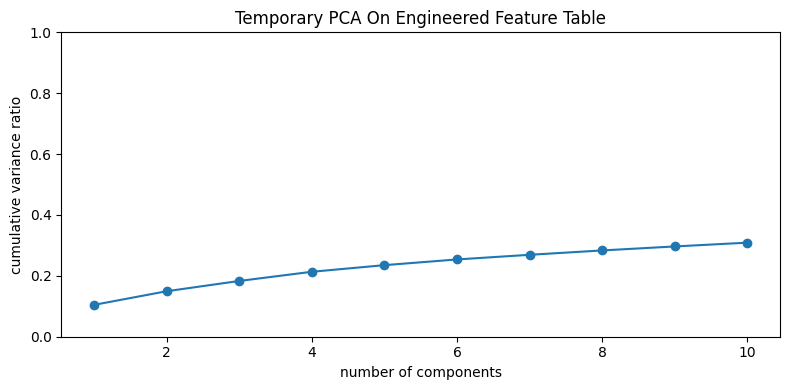

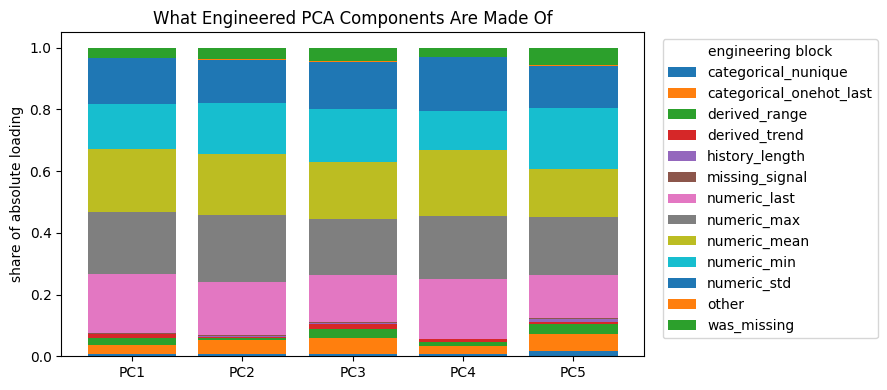

In [10]:
REPORTS = Path('../reports/feature_engineering')
REPORTS.mkdir(parents=True, exist_ok=True)

def engineered_base(feature):
    feature = str(feature)
    if '__' in feature:
        return feature.split('__', 1)[0]
    if feature.endswith('_missing_flag'):
        return feature[:-len('_missing_flag')]
    if feature.endswith('_missing'):
        return feature[:-len('_missing')]
    return feature

def engineered_group(feature):
    base = engineered_base(feature)
    return base.split('_', 1)[0] if '_' in base else 'other'

def engineering_block(feature):
    feature = str(feature)
    if '__' in feature:
        suffix = feature.split('__', 1)[1]
        if suffix in {'mean', 'std', 'min', 'max', 'last'}:
            return f'numeric_{suffix}'
        if suffix == 'nunique':
            return 'categorical_nunique'
        if suffix.startswith('last_'):
            return 'categorical_onehot_last'
        if suffix in {'range', 'trend'}:
            return f'derived_{suffix}'
        return suffix
    if feature.endswith('_missing_flag') or feature.endswith('_missing') or 'missing' in feature:
        return 'missing_signal'
    if feature in {'statement_count', 'customer_span_days'}:
        return 'history_length'
    if any(token in feature for token in ['ratio', 'utilization', 'payment_gap']):
        return 'derived_ratio'
    return 'other'

X_fe = features.drop(columns='target')
y_fe = features['target'].astype(int)

pca_audit = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=5241)),
])
pca_audit.fit(X_fe)
pca_model = pca_audit.named_steps['pca']
pc_cols = [f'PC{i}' for i in range(1, pca_model.components_.shape[0] + 1)]
loadings = pd.DataFrame(pca_model.components_.T, index=X_fe.columns, columns=pc_cols)

rows = []
summary_rows = []
for pc in pc_cols[:5]:
    s = loadings[pc].sort_values()
    negative = s.head(8)
    positive = s.tail(8).sort_values(ascending=False)
    for feature, loading in pd.concat([negative, positive]).items():
        rows.append({
            'component': pc,
            'feature': feature,
            'base_feature': engineered_base(feature),
            'feature_group': engineered_group(feature),
            'engineering_block': engineering_block(feature),
            'loading': loading,
            'abs_loading': abs(loading),
            'direction': 'positive' if loading > 0 else 'negative',
        })
    summary_rows.append({
        'component': pc,
        'explained_variance_ratio': pca_model.explained_variance_ratio_[int(pc[2:]) - 1],
        'positive_side': ', '.join([f'{f} ({v:+.2f})' for f, v in positive.head(5).items()]),
        'negative_side': ', '.join([f'{f} ({v:+.2f})' for f, v in negative.head(5).items()]),
        'plain_english_read': (
            f"Higher {pc} is associated with engineered columns like " + ', '.join(positive.head(3).index) +
            '; lower values are associated with ' + ', '.join(negative.head(3).index)
        ),
    })

pca_loading_audit = pd.DataFrame(rows).sort_values(['component', 'abs_loading'], ascending=[True, False])
pca_component_summary = pd.DataFrame(summary_rows)

block_rows = []
group_rows = []
for pc in pc_cols[:5]:
    block = loadings[pc].abs().groupby([engineering_block(f) for f in loadings.index]).sum()
    block = (block / block.sum()).sort_values(ascending=False)
    for name, share in block.items():
        block_rows.append({'component': pc, 'engineering_block': name, 'abs_loading_share': share})
    group = loadings[pc].abs().groupby([engineered_group(f) for f in loadings.index]).sum()
    group = (group / group.sum()).sort_values(ascending=False)
    for name, share in group.items():
        group_rows.append({'component': pc, 'feature_group': name, 'abs_loading_share': share})

pca_block_contrib = pd.DataFrame(block_rows)
pca_group_contrib = pd.DataFrame(group_rows)

pca_loading_audit.to_csv(REPORTS / 'engineered_pca_top_loadings.csv', index=False)
pca_component_summary.to_csv(REPORTS / 'engineered_pca_component_interpretation.csv', index=False)
pca_block_contrib.to_csv(REPORTS / 'engineered_pca_block_contributions.csv', index=False)
pca_group_contrib.to_csv(REPORTS / 'engineered_pca_group_contributions.csv', index=False)

display(pca_component_summary)
display(pca_block_contrib.pivot(index='component', columns='engineering_block', values='abs_loading_share').fillna(0).round(3))
display(pca_group_contrib.pivot(index='component', columns='feature_group', values='abs_loading_share').fillna(0).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
cum_var = np.cumsum(pca_model.explained_variance_ratio_)
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
ax.set_title('Temporary PCA On Engineered Feature Table')
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative variance ratio')
ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig(REPORTS / 'engineered_pca_cumulative_variance.png', dpi=160); plt.show()

pivot = pca_block_contrib.pivot(index='component', columns='engineering_block', values='abs_loading_share').fillna(0)
fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(pivot))
for block in pivot.columns:
    ax.bar(pivot.index, pivot[block], bottom=bottom, label=block)
    bottom += pivot[block].to_numpy()
ax.set_title('What Engineered PCA Components Are Made Of')
ax.set_ylabel('share of absolute loading')
ax.legend(title='engineering block', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout(); fig.savefig(REPORTS / 'engineered_pca_block_contributions.png', dpi=160); plt.show()
